In [1]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, LSTM, Dropout, Attention, Permute, Multiply, Lambda, Concatenate, GlobalAveragePooling1D, BatchNormalization

2026-01-13 10:50:55.312231: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768301455.764174      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768301455.894585      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
import numpy as np
import pandas as pd

# Paths
pre_processed_data = "/kaggle/input/pre-processed/left_hand_acc/left_hand_acc"

# Load numpy files
x = np.load(f"{pre_processed_data}/X_windows_left_2s_10_full_ds.npy")
y_disease = np.load(f"{pre_processed_data}/Y_disease_left_2s_10_labels.npy")
y_activity = np.load(f"{pre_processed_data}/Y_activity_left_2s_10_labels.npy")
y_gender = np.load(f"{pre_processed_data}/gender.npy")
y_id = np.load(f"{pre_processed_data}/ids.npy")

print("Shapes:")
print("X:", x.shape)            # (num_samples, timesteps, features)
print("Disease:", y_disease.shape)
print("Activity:", y_activity.shape)
print("Gender:", y_gender.shape)
print("IDs:", y_id.shape)

Shapes:
X: (288144, 200, 3)
Disease: (288144,)
Activity: (288144,)
Gender: (288144,)
IDs: (288144,)


num_samples = x.shape[0]
x_flat = x.reshape(num_samples, -1)   # Flatten to 2D

# Create dataframe
df = pd.DataFrame(x_flat)

# Add labels as extra columns
df["Disease"] = y_disease
df["Activity"] = y_activity
df["Gender"] = y_gender
df["Subject_ID"] = y_id

# Save to CSV
output_csv = "accelerometer_dataset.csv"
df.to_csv(output_csv, index=False)

print(f"✅ Dataset saved to {output_csv}")


df.head()

In [3]:
# ---- Scaling whole dataset ----

from sklearn.preprocessing import StandardScaler

# Dataset dimensions
N, T, F = x.shape
print(f"Original shape: (N={N}, T={T}, F={F})")

# Flatten to (N*T, F) for scaling
X_2d = x.reshape(-1, F)

# Fit & transform with StandardScaler
scaler = StandardScaler()
X_scaled_2d = scaler.fit_transform(X_2d)

# Reshape back to (N, T, F)
X_scaled = X_scaled_2d.reshape(N, T, F)

print("✅ Scaling complete")
print("Scaled shape:", X_scaled.shape)

# Check mean & std of first feature
print("Feature[0] mean (should be ~0):", X_scaled[..., 0].mean())
print("Feature[0] std (should be ~1):", X_scaled[..., 0].std())

# Preview first sample (first 3 timesteps)
print("\nFirst sample (first 3 timesteps):")
print(X_scaled[0, :3, :])


Original shape: (N=288144, T=200, F=3)
✅ Scaling complete
Scaled shape: (288144, 200, 3)
Feature[0] mean (should be ~0): -3.21969e-09
Feature[0] std (should be ~1): 1.0000001

First sample (first 3 timesteps):
[[ 0.10832798 -0.08097341 -0.02066287]
 [ 0.10799944 -0.07559638 -0.02029927]
 [ 0.09076368 -0.07654238 -0.01326593]]


In [4]:
import pandas as pd
(unique, counts) = np.unique(y_disease, return_counts=True)
print(pd.DataFrame({'class': unique, 'count': counts}))

   class   count
0      0   48533
1      1  169565
2      2   70046


In [5]:
import pandas as pd
(unique, counts) = np.unique(y_gender, return_counts=True)
print(pd.DataFrame({'class': unique, 'count': counts}))

   class   count
0      0  115497
1      1  172647


In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Build dataframe with disease + gender
df = pd.DataFrame({
    "disease": y_disease,
    "activity": y_activity,
    "gender": y_gender
})
df["idx"] = np.arange(len(df))

# Separate classes
df_class1 = df[df["disease"] == 1]
df_class0 = df[df["disease"] == 0]
df_class2 = df[df["disease"] == 2]

# ---- Split Class 1 into 80k vs remaining, stratified by gender ----
df_class1_train, df_class1_finetune = train_test_split(
    df_class1,
    train_size=80000,
    stratify=df_class1["gender"],   # balance genders
    random_state=42
)

# ---- Build chunks ----
df_chunk1 = pd.concat([df_class1_train, df_class0, df_class2])
df_chunk2 = pd.concat([df_class1_finetune, df_class0, df_class2])

# Recover indices
chunk1_idx = df_chunk1["idx"].values
chunk2_idx = df_chunk2["idx"].values

# Subset arrays
X_train = X_scaled[chunk1_idx]
y_disease_train = y_disease[chunk1_idx]
y_activity_train = y_activity[chunk1_idx]

X_finetune = X_scaled[chunk2_idx]
y_disease_finetune = y_disease[chunk2_idx]
y_activity_finetune = y_activity[chunk2_idx]

print("Chunk1 (train) shapes:", X_train.shape, y_disease_train.shape, y_activity_train.shape)
print("Chunk2 (finetune) shapes:", X_finetune.shape, y_disease_finetune.shape, y_activity_finetune.shape)

# Check gender distribution inside Class 1 split
print("\nGender distribution in Class 1 Train:\n", df_class1_train["gender"].value_counts())
print("\nGender distribution in Class 1 Finetune:\n", df_class1_finetune["gender"].value_counts())


Chunk1 (train) shapes: (198579, 200, 3) (198579,) (198579,)
Chunk2 (finetune) shapes: (208144, 200, 3) (208144,) (208144,)

Gender distribution in Class 1 Train:
 gender
1    56525
0    23475
Name: count, dtype: int64

Gender distribution in Class 1 Finetune:
 gender
1    63283
0    26282
Name: count, dtype: int64


In [7]:
def check_distribution(name, idx, y_disease, y_gender):
    df = pd.DataFrame({
        "disease": y_disease[idx],
        "gender": y_gender[idx]
    })
    print(f"\n{name} distribution:")
    print("Disease counts:\n", df["disease"].value_counts().sort_index())
    print("Gender counts:\n", df["gender"].value_counts())
    print("Disease x Gender:\n", pd.crosstab(df["disease"], df["gender"]))
    print("Unique IDs:", df.shape[0])  # total samples

# Check both chunks
check_distribution("Chunk1 (Train)", chunk1_idx, y_disease, y_gender)
check_distribution("Chunk2 (Finetune)", chunk2_idx, y_disease, y_gender)



Chunk1 (Train) distribution:
Disease counts:
 disease
0    48533
1    80000
2    70046
Name: count, dtype: int64
Gender counts:
 gender
1    109364
0     89215
Name: count, dtype: int64
Disease x Gender:
 gender       0      1
disease              
0        30717  17816
1        23475  56525
2        35023  35023
Unique IDs: 198579

Chunk2 (Finetune) distribution:
Disease counts:
 disease
0    48533
1    89565
2    70046
Name: count, dtype: int64
Gender counts:
 gender
1    116122
0     92022
Name: count, dtype: int64
Disease x Gender:
 gender       0      1
disease              
0        30717  17816
1        26282  63283
2        35023  35023
Unique IDs: 208144


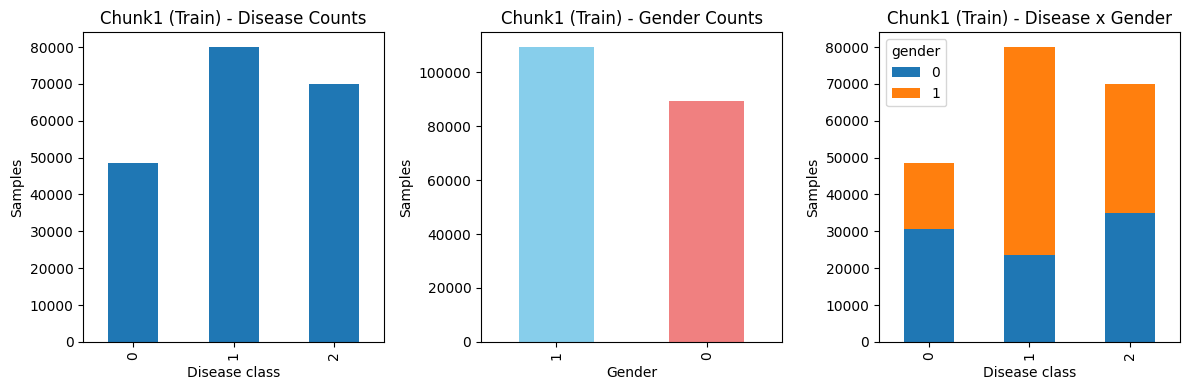

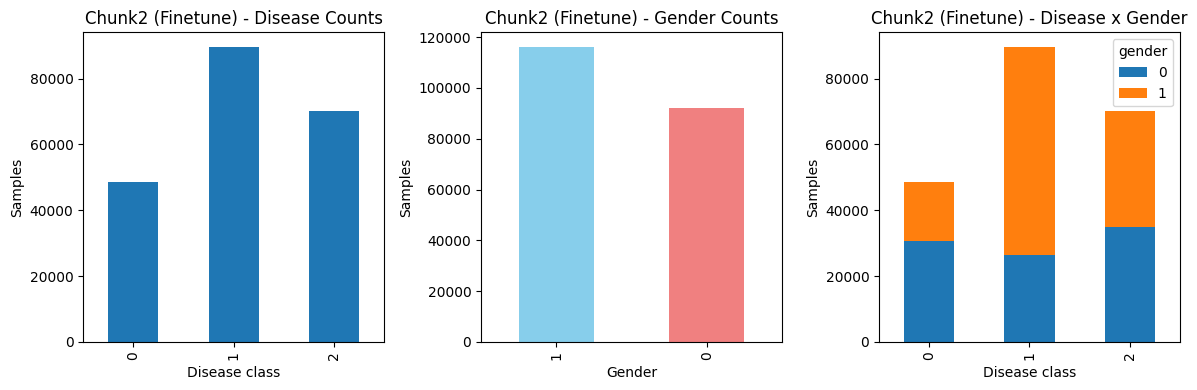

In [8]:
import matplotlib.pyplot as plt

def plot_distribution(name, idx, y_disease, y_gender):
    df = pd.DataFrame({
        "disease": y_disease[idx],
        "gender": y_gender[idx]
    })
    
    # Disease counts
    disease_counts = df["disease"].value_counts().sort_index()
    gender_counts = df["gender"].value_counts()
    cross_tab = pd.crosstab(df["disease"], df["gender"])
    
    # --- Plot disease counts ---
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    disease_counts.plot(kind="bar")
    plt.title(f"{name} - Disease Counts")
    plt.xlabel("Disease class")
    plt.ylabel("Samples")
    
    # --- Plot gender counts ---
    plt.subplot(1, 3, 2)
    gender_counts.plot(kind="bar", color=["skyblue", "lightcoral"])
    plt.title(f"{name} - Gender Counts")
    plt.xlabel("Gender")
    plt.ylabel("Samples")
    
    # --- Plot disease × gender cross tab ---
    plt.subplot(1, 3, 3)
    cross_tab.plot(kind="bar", stacked=True, ax=plt.gca())
    plt.title(f"{name} - Disease x Gender")
    plt.xlabel("Disease class")
    plt.ylabel("Samples")
    
    plt.tight_layout()
    plt.show()

# Plot for both chunks
plot_distribution("Chunk1 (Train)", chunk1_idx, y_disease, y_gender)
plot_distribution("Chunk2 (Finetune)", chunk2_idx, y_disease, y_gender)


In [9]:
from sklearn.model_selection import train_test_split

# Step 1: Train vs Temp (20% goes to Temp)
X_train_final, X_temp, y_disease_train_final, y_disease_temp, y_activity_train_final, y_activity_temp = train_test_split(
    X_train, y_disease_train, y_activity_train,
    test_size=0.2,
    random_state=42,
    stratify=y_disease_train
)

# Step 2: Split Temp equally into Val and Test
X_val, X_test, y_disease_val, y_disease_test, y_activity_val, y_activity_test = train_test_split(
    X_temp, y_disease_temp, y_activity_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_disease_temp
)

print("Train shapes:", X_train_final.shape, y_disease_train_final.shape, y_activity_train_final.shape)
print("Val shapes:", X_val.shape, y_disease_val.shape, y_activity_val.shape)
print("Test shapes:", X_test.shape, y_disease_test.shape, y_activity_test.shape)


Train shapes: (158863, 200, 3) (158863,) (158863,)
Val shapes: (19858, 200, 3) (19858,) (19858,)
Test shapes: (19858, 200, 3) (19858,) (19858,)


In [10]:
import numpy as np
from collections import Counter

print("Train disease distribution:", Counter(y_disease_train_final))
print("Val disease distribution:", Counter(y_disease_val))
print("Test disease distribution:", Counter(y_disease_test))
print("Train activity distribution:", Counter(y_activity_train_final))
print("Val activity distribution:", Counter(y_activity_val))
print("Test activity distribution:", Counter(y_activity_test))

Train disease distribution: Counter({1: 64000, 2: 56037, 0: 38826})
Val disease distribution: Counter({1: 8000, 2: 7004, 0: 4854})
Test disease distribution: Counter({1: 8000, 2: 7005, 0: 4853})
Train activity distribution: Counter({2: 26499, 6: 26426, 5: 13346, 7: 13313, 4: 13258, 3: 13255, 1: 13223, 0: 13206, 8: 13205, 9: 13132})
Val activity distribution: Counter({6: 3318, 2: 3221, 8: 1727, 4: 1710, 7: 1682, 0: 1666, 5: 1659, 9: 1643, 3: 1631, 1: 1601})
Test activity distribution: Counter({6: 3324, 2: 3303, 0: 1668, 9: 1663, 4: 1660, 7: 1659, 8: 1654, 1: 1652, 5: 1651, 3: 1624})


In [11]:
from sklearn.utils.class_weight import compute_class_weight
disease_classes = np.unique(y_disease_train_final)
disease_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=disease_classes,
    y=y_disease_train_final
)

# Convert to dictionary: {class_index: weight}
disease_class_weights = {i: w for i, w in zip(disease_classes, disease_weights_array)}
print("Disease class weights:", disease_class_weights)


Disease class weights: {0: 1.3638884596232765, 1: 0.8274114583333333, 2: 0.9449887276858742}


In [12]:
print("y_disease_train shape:", y_disease_train_final.shape)
print("sample_weights[0] shape:", np.array([disease_class_weights[c] for c in y_disease_train_final]).shape)

print("y_activity_train shape:", y_activity_train_final.shape)
print("sample_weights[1] shape:", np.ones(len(y_activity_train_final)).shape)


y_disease_train shape: (158863,)
sample_weights[0] shape: (158863,)
y_activity_train shape: (158863,)
sample_weights[1] shape: (158863,)


In [13]:
from tensorflow.keras import layers, Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import f1_score
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
from tensorflow.keras.optimizers import AdamW

In [14]:
def build_self_attention_block(x, num_heads, key_dim, dropout_rate):
    """
    Input shape : (batch, time, features)
    Output shape: (batch, time, features)
    """

    attn_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim // num_heads,  # IMPORTANT
        dropout=dropout_rate
    )(x, x)

    # Residual connection
    x = layers.Add()([x, attn_output])
    x = layers.LayerNormalization()(x)

    return x


In [15]:
def build_multi_task_model(timesteps=200, features=3,
                           num_disease=3, num_activities=10,
                           lstm_units=64, dense_units=64,
                           dropout_rate=0.15):
    input_layer = layers.Input(shape=(timesteps, features), name="inputs")
    # ---- CNN Block 1 ----
    x = layers.Conv1D(filters=64, kernel_size=7, padding="same",
                      activation="relu", kernel_regularizer=l2(1e-5))(input_layer)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    # ---- CNN Block 2 ----
    x = layers.Conv1D(filters=64, kernel_size=5, padding="same",
                      activation="relu", kernel_regularizer=l2(1e-5))(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.MaxPooling1D(pool_size=2, strides=2, padding="valid")(x)
    x = layers.LSTM(lstm_units, return_sequences=True,
                kernel_regularizer=l2(1e-5))(x)

    x = build_self_attention_block(
        x,
         num_heads=4,
        key_dim=lstm_units,
        dropout_rate=dropout_rate
    )

    x = layers.GlobalAveragePooling1D()(x)

    
    # ---- Dense projection ----
    x = layers.Dense(dense_units, activation="relu", kernel_regularizer=l2(1e-5))(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    # ---- Outputs ----
    disease_output = layers.Dense(num_disease, activation="softmax", name="disease_output")(x)
    activity_output = layers.Dense(num_activities, activation="softmax", name="activity_output")(x)

    model = Model(inputs=input_layer, outputs=[disease_output, activity_output])
    return model


In [16]:
# ---- Callbacks ----
def get_callbacks(checkpoint_dir="/content/checkpoints"):
    checkpoint_path = checkpoint_dir + "/epoch_{epoch:02d}_val_loss_{val_loss:.4f}.h5"
    checkpoint_callback = ModelCheckpoint(
        filepath=checkpoint_path,
        save_weights_only=False,
        save_freq="epoch",
        monitor="val_loss",
        save_best_only=True,  # keep only best
        verbose=1,
    )
    return [checkpoint_callback]

In [17]:
# ---- Custom F1 Callback ----
class F1ScoreCallback(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val_d, y_val_a):
        super().__init__()
        self.X_val = X_val
        self.y_val_d = y_val_d
        self.y_val_a = y_val_a

    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.model.predict(self.X_val, verbose=0)
        y_pred_disease = np.argmax(y_pred[0], axis=1)
        y_pred_activity = np.argmax(y_pred[1], axis=1)

        f1_disease = f1_score(self.y_val_d, y_pred_disease, average="macro")
        f1_activity = f1_score(self.y_val_a, y_pred_activity, average="macro")

        print(f"\nEpoch {epoch+1} - Val Macro F1 (Disease): {f1_disease:.4f}, (Activity): {f1_activity:.4f}")

In [18]:
def get_callbacks(checkpoint_dir="checkpoints", fold_no=None, save_every=10):

    os.makedirs(checkpoint_dir, exist_ok=True)

    # Best model (.keras format)
    best_model_path = os.path.join(
        checkpoint_dir,
        f"best_model_fold_{fold_no}.keras" if fold_no is not None else "best_model.keras"
    )

    checkpoint_best = ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )

    # Periodic save every epoch (Keras limitation)
    periodic_model_path = os.path.join(
        checkpoint_dir,
        f"model_epoch_{{epoch:02d}}_fold_{fold_no}.keras" if fold_no is not None
        else "model_epoch_{epoch:02d}.keras"
    )

    checkpoint_periodic = ModelCheckpoint(
        filepath=periodic_model_path,
        save_freq="epoch",   # <── FIXED
        save_weights_only=False,
        verbose=1
    )

    return [checkpoint_best, checkpoint_periodic]


In [19]:
import os
# ============================================
# 1️⃣ Build Multi-Task Model
# ============================================
input_shape = (X_train_final.shape[1], X_train_final.shape[2])
num_disease = len(np.unique(y_disease_train_final))
num_activities = len(np.unique(y_activity_train_final))

model = build_multi_task_model(
    timesteps=input_shape[0],
    features=input_shape[1],
    num_disease=num_disease,
    num_activities=num_activities
)

# ============================================
# 2️⃣ Compile Model
# ============================================
batch_size = 512
epochs = 100
steps_per_epoch = len(X_train_final) // batch_size

lr_schedule = CosineDecayRestarts(
    initial_learning_rate=1e-3,
    first_decay_steps=steps_per_epoch * (epochs // 3),
    t_mul=2.0,
    m_mul=0.8
)

optimizer = AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-5,
    clipnorm=1.0
)

model.compile(
    optimizer=optimizer,
    loss={
        "disease_output": "sparse_categorical_crossentropy",
        "activity_output": "sparse_categorical_crossentropy"
    },
    metrics={
        "disease_output": ["accuracy"],
        "activity_output": ["accuracy"]
    }
)

# ============================================
# 3️⃣ Prepare Callbacks (Checkpoints + F1)
# ============================================
callbacks = get_callbacks(checkpoint_dir="checkpoints") + [
    F1ScoreCallback(X_val, y_disease_val, y_activity_val)
]

# ============================================
# 4️⃣ Train Model
# ============================================
history = model.fit(
    X_train_final,
    {
        "disease_output": y_disease_train_final,
        "activity_output": y_activity_train_final
    },
    validation_data=(
        X_val,
        {
            "disease_output": y_disease_val,
            "activity_output": y_activity_val
        }
    ),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=callbacks,
    verbose=1
)

# ============================================
# 5️⃣ Print Per-Epoch Metrics (Loss + Accuracy + F1)
# ============================================
for epoch in range(len(history.history["loss"])):
    train_loss = history.history["loss"][epoch]
    val_loss = history.history["val_loss"][epoch]
    train_acc_d = history.history["disease_output_accuracy"][epoch]
    val_acc_d = history.history["val_disease_output_accuracy"][epoch]
    train_acc_a = history.history["activity_output_accuracy"][epoch]
    val_acc_a = history.history["val_activity_output_accuracy"][epoch]
    
    print(f"Epoch {epoch+1}/{epochs}:")
    print(f"  Loss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
    print(f"  Accuracy - Disease: Train {train_acc_d:.4f}, Val {val_acc_d:.4f}")
    print(f"  Accuracy - Activity: Train {train_acc_a:.4f}, Val {val_acc_a:.4f}")


I0000 00:00:1768301496.386524      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768301496.387136      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/100


I0000 00:00:1768301508.232157     173 cuda_dnn.cc:529] Loaded cuDNN version 90300


311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - activity_output_accuracy: 0.5496 - activity_output_loss: 1.3768 - disease_output_accuracy: 0.4098 - disease_output_loss: 1.1203 - loss: 2.4995
Epoch 1: val_loss improved from inf to 1.81873, saving model to checkpoints/best_model.keras

Epoch 1: saving model to checkpoints/model_epoch_01.keras

Epoch 1 - Val Macro F1 (Disease): 0.4532, (Activity): 0.6909
311/311 ━━━━━━━━━━━━━━━━━━━━ 39s 83ms/step - activity_output_accuracy: 0.5499 - activity_output_loss: 1.3757 - disease_output_accuracy: 0.4098 - disease_output_loss: 1.1201 - loss: 2.4983 - val_activity_output_accuracy: 0.7284 - val_activity_output_loss: 0.8166 - val_disease_output_accuracy: 0.4700 - val_disease_output_loss: 0.9997 - val_loss: 1.8187
Epoch 2/100
310/311 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - activity_output_accuracy: 0.7567 - activity_output_loss: 0.7440 - disease_output_accuracy: 0.4785 - disease_output_loss: 0.9949 - loss: 1.7415
Epoch 2: val_loss improved from 1.81873 to 1.63

In [20]:
import time
import numpy as np
import tensorflow as tf

def measure_inference_time(model, X, batch_size=512, runs=20):

    X_batch = X[:batch_size]

    # Warm-up
    for _ in range(5):
        model.predict(X_batch, batch_size=batch_size, verbose=0)

    start = time.time()

    for _ in range(runs):
        outputs = model.predict(X_batch, batch_size=batch_size, verbose=0)
        # Force sync
        if isinstance(outputs, list):
            np.asarray(outputs[0])
        else:
            np.asarray(outputs)

    end = time.time()

    avg_batch_time_ms = ((end - start) / runs) * 1000
    avg_sample_time_ms = avg_batch_time_ms / batch_size

    return avg_batch_time_ms, avg_sample_time_ms


In [21]:
batch_ms, sample_ms = measure_inference_time(model, X_val)
print(batch_ms, sample_ms)


70.63868045806885 0.13796617276966572


In [22]:
import os

# Save directory inside Kaggle working
save_dir = "/kaggle/working"
os.makedirs(save_dir, exist_ok=True)

# Model path (use .keras extension for Keras 3.x)
model_path = os.path.join(save_dir, "cnn_lstm_atten_2_10_early_left.keras")

# Save model
model.save(model_path)

print(f"✅ Model saved at: {model_path}")

✅ Model saved at: /kaggle/working/cnn_lstm_atten_2_10_early_left.keras


dict_keys(['activity_output_accuracy', 'activity_output_loss', 'disease_output_accuracy', 'disease_output_loss', 'loss', 'val_activity_output_accuracy', 'val_activity_output_loss', 'val_disease_output_accuracy', 'val_disease_output_loss', 'val_loss'])


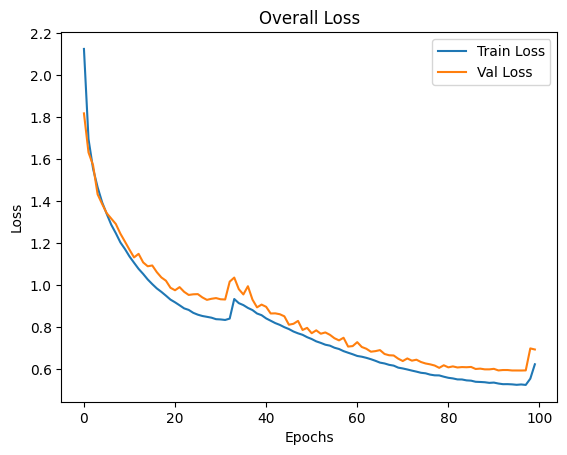

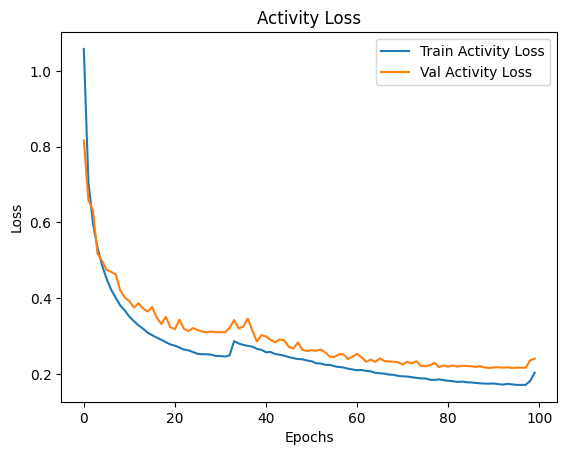

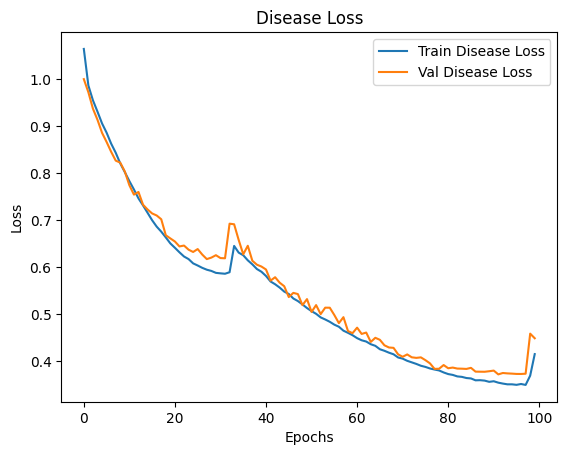

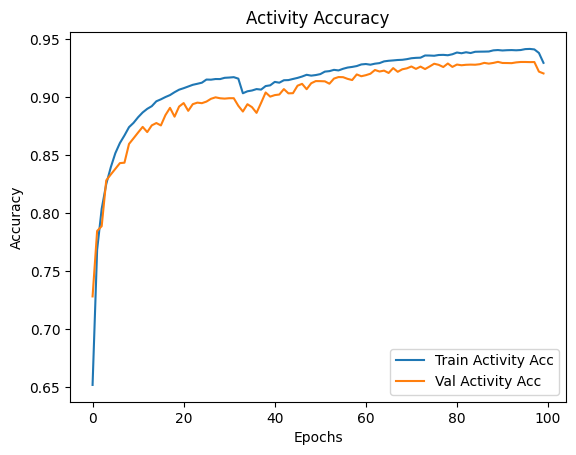

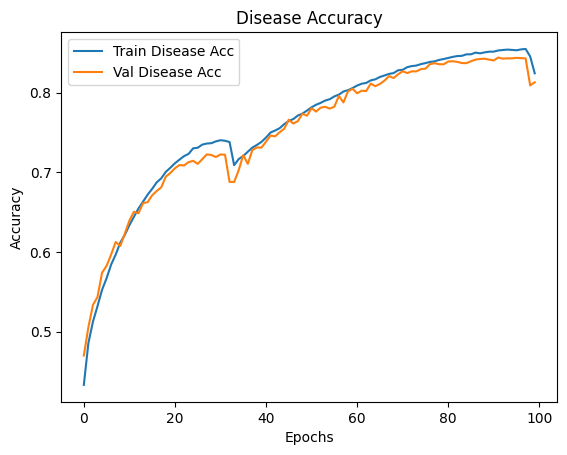

In [23]:
import matplotlib.pyplot as plt

# Utility function to plot training curves
def plot_history(history):
    # ---- Overall Loss ----
    plt.figure()
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Overall Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()

    # ---- Activity Loss ----
    plt.figure()
    plt.plot(history.history["activity_output_loss"], label="Train Activity Loss")
    plt.plot(history.history["val_activity_output_loss"], label="Val Activity Loss")
    plt.legend()
    plt.title("Activity Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()

    # ---- Disease Loss ----
    plt.figure()
    plt.plot(history.history["disease_output_loss"], label="Train Disease Loss")
    plt.plot(history.history["val_disease_output_loss"], label="Val Disease Loss")
    plt.legend()
    plt.title("Disease Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()

    # ---- Activity Accuracy ----
    plt.figure()
    plt.plot(history.history["activity_output_accuracy"], label="Train Activity Acc")
    plt.plot(history.history["val_activity_output_accuracy"], label="Val Activity Acc")
    plt.legend()
    plt.title("Activity Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.show()

    # ---- Disease Accuracy ----
    plt.figure()
    plt.plot(history.history["disease_output_accuracy"], label="Train Disease Acc")
    plt.plot(history.history["val_disease_output_accuracy"], label="Val Disease Acc")
    plt.legend()
    plt.title("Disease Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.show()
# After training
print(history.history.keys())  # check available metrics

# Then plot
plot_history(history)


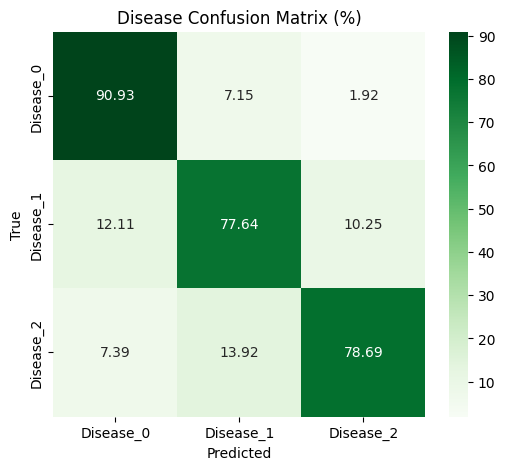


Disease Classification Report:
              precision    recall  f1-score   support

   Disease_0     0.7480    0.9093    0.8208      4853
   Disease_1     0.8245    0.7764    0.7997      8000
   Disease_2     0.8579    0.7869    0.8208      7005

    accuracy                         0.8126     19858
   macro avg     0.8101    0.8242    0.8138     19858
weighted avg     0.8176    0.8126    0.8123     19858


Activity Classification Report:
              precision    recall  f1-score   support

  Activity_0     0.8727    0.8633    0.8680      1668
  Activity_1     0.9127    0.8801    0.8961      1652
  Activity_2     0.9845    0.9622    0.9732      3303
  Activity_3     0.9525    0.9514    0.9519      1624
  Activity_4     0.8363    0.8741    0.8548      1660
  Activity_5     0.9596    0.9491    0.9543      1651
  Activity_6     0.9746    0.9801    0.9774      3324
  Activity_7     0.8698    0.9017    0.8855      1659
  Activity_8     0.8260    0.9129    0.8673      1654
  Activity_9 

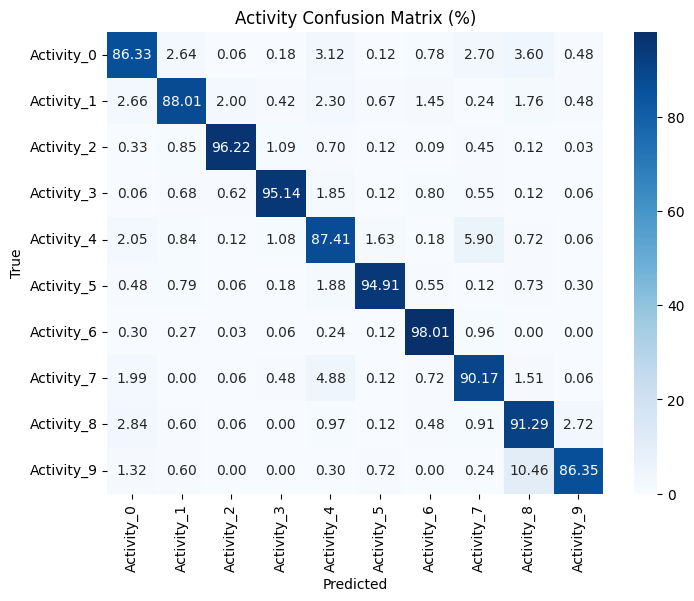

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ---- Predictions ----
y_pred_test = model.predict(X_test, verbose=0)

# Convert softmax outputs → integer class predictions
y_pred_disease = np.argmax(y_pred_test[0], axis=1)
y_pred_activity = np.argmax(y_pred_test[1], axis=1)

# ---- Ensure y_test are integers (not one-hot) ----
if y_disease_test.ndim > 1:  
    y_disease_test = np.argmax(y_disease_test, axis=1)

if y_activity_test.ndim > 1:  
    y_activity_test = np.argmax(y_activity_test, axis=1)


cm_disease = confusion_matrix(y_disease_test, y_pred_disease, labels=disease_classes)
# 🔹 Convert counts → row-wise percentages
cm_disease_pct = cm_disease.astype("float") / cm_disease.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(6,5))
sns.heatmap(cm_disease_pct, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=[f"Disease_{i}" for i in disease_classes],
            yticklabels=[f"Disease_{i}" for i in disease_classes])
plt.title("Disease Confusion Matrix (%)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# ---- Disease Classification Report ----
print("\nDisease Classification Report:")
disease_classes = np.unique(np.concatenate([y_disease_test, y_pred_disease]))
print(classification_report(
    y_disease_test,
    y_pred_disease,
    labels=disease_classes,
    target_names=[f"Disease_{i}" for i in disease_classes],
    digits=4
))
# ---- Activity Classification Report ----
print("\nActivity Classification Report:")
activity_classes = np.unique(np.concatenate([y_activity_test, y_pred_activity]))
print(classification_report(
    y_activity_test,
    y_pred_activity,
    labels=activity_classes,
    target_names=[f"Activity_{i}" for i in activity_classes],
    digits=4
))

cm_activity = confusion_matrix(y_activity_test, y_pred_activity, labels=activity_classes)
# 🔹 Convert counts → row-wise percentages
cm_activity_pct = cm_activity.astype("float") / cm_activity.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(8,6))
sns.heatmap(cm_activity_pct, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=[f"Activity_{i}" for i in activity_classes],
            yticklabels=[f"Activity_{i}" for i in activity_classes])
plt.title("Activity Confusion Matrix (%)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [25]:
from sklearn.model_selection import train_test_split

X_train_f, X_temp_f, y_disease_train_f, y_disease_temp_f, y_activity_train_f, y_activity_temp_f = train_test_split(
    X_finetune,
    y_disease_finetune,
    y_activity_finetune,
    test_size=0.3,
    random_state=42,
    stratify=y_disease_finetune
)

X_val_f, X_test_f, y_disease_val_f, y_disease_test_f, y_activity_val_f, y_activity_test_f = train_test_split(
    X_temp_f,
    y_disease_temp_f,
    y_activity_temp_f,
    test_size=0.5,
    random_state=42,
    stratify=y_disease_temp_f
)

print("Train:", X_train_f.shape, "Val:", X_val_f.shape, "Test:", X_test_f.shape)

Train: (145700, 200, 3) Val: (31222, 200, 3) Test: (31222, 200, 3)


In [26]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

In [27]:
from sklearn.metrics import f1_score, accuracy_score
import numpy as np
import keras

class MetricsCallback(keras.callbacks.Callback):
    def __init__(self, val_data):
        super().__init__()
        self.validation_data = val_data

    def on_epoch_end(self, epoch, logs=None):
        X_val, y_val_dict = self.validation_data
        y_disease_val = y_val_dict["disease_output"]
        y_activity_val = y_val_dict["activity_output"]

        # Predictions
        y_pred = self.model.predict(X_val, verbose=0)
        y_pred_disease = np.argmax(y_pred[0], axis=1)
        y_pred_activity = np.argmax(y_pred[1], axis=1)

        # Metrics for disease
        f1_disease = f1_score(y_disease_val, y_pred_disease, average="macro")
        acc_disease = accuracy_score(y_disease_val, y_pred_disease)

        # Metrics for activity
        f1_activity = f1_score(y_activity_val, y_pred_activity, average="macro")
        acc_activity = accuracy_score(y_activity_val, y_pred_activity)

        print(
            f"\nEpoch {epoch+1} — "
            f"Disease F1: {f1_disease:.4f}, Acc: {acc_disease:.4f} | "
            f"Activity F1: {f1_activity:.4f}, Acc: {acc_activity:.4f}"
        )


In [32]:
import tensorflow as tf
from keras.callbacks import ReduceLROnPlateau

# ✅ Recompile the pretrained model with a fixed float learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # must be float, not schedule
    loss={
        "disease_output": "sparse_categorical_crossentropy",
        "activity_output": "sparse_categorical_crossentropy"
    },
    metrics={
        "disease_output": ["accuracy"],
        "activity_output": ["accuracy"]
    }
)

# ✅ Use only learning rate scheduler
reduce_lr = ReduceLROnPlateau(
    monitor="val_disease_output_accuracy",
    factor=0.5,
    patience=4,
    mode="max",
    verbose=1
)

# ✅ Fine-tuning using TRAIN + VALIDATION splits
history_finetune = model.fit(
    X_train_f,
    {
        "disease_output": y_disease_train_f,
        "activity_output": y_activity_train_f
    },
    validation_data=(
        X_val_f,
        {
            "disease_output": y_disease_val_f,
            "activity_output": y_activity_val_f
        }
    ),
    epochs=50,
    batch_size=512,
    callbacks=[reduce_lr],
    verbose=1
)


Epoch 1/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - activity_output_accuracy: 0.9308 - activity_output_loss: 0.2029 - disease_output_accuracy: 0.8462 - disease_output_loss: 0.3651 - loss: 0.5742 - val_activity_output_accuracy: 0.9376 - val_activity_output_loss: 0.1879 - val_disease_output_accuracy: 0.8634 - val_disease_output_loss: 0.3350 - val_loss: 0.5292 - learning_rate: 1.0000e-04
Epoch 2/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - activity_output_accuracy: 0.9299 - activity_output_loss: 0.2042 - disease_output_accuracy: 0.8472 - disease_output_loss: 0.3636 - loss: 0.5740 - val_activity_output_accuracy: 0.9391 - val_activity_output_loss: 0.1837 - val_disease_output_accuracy: 0.8605 - val_disease_output_loss: 0.3408 - val_loss: 0.5307 - learning_rate: 1.0000e-04
Epoch 3/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step - activity_output_accuracy: 0.9307 - activity_output_loss: 0.2058 - disease_output_accuracy: 0.8453 - disease_output_loss: 0.3656 - loss: 0.5777 - val_activity_ou

In [33]:
# Save fine-tuned model
save_path = "/kaggle/working/ft_model_cnn_lstm_atten_2_10_early_left.keras"
model.save(save_path)
print(f"✅ Fine-tuned model saved at: {save_path}")

✅ Fine-tuned model saved at: /kaggle/working/ft_model_cnn_lstm_atten_2_10_early_left.keras


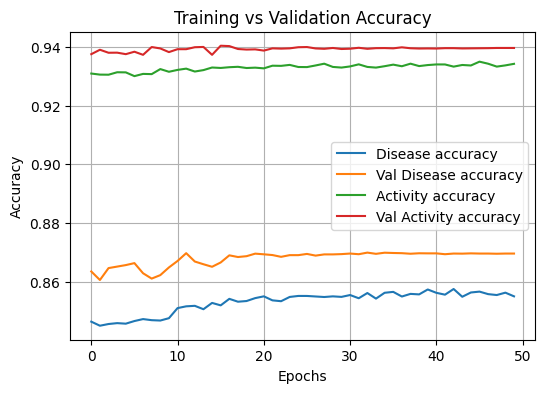

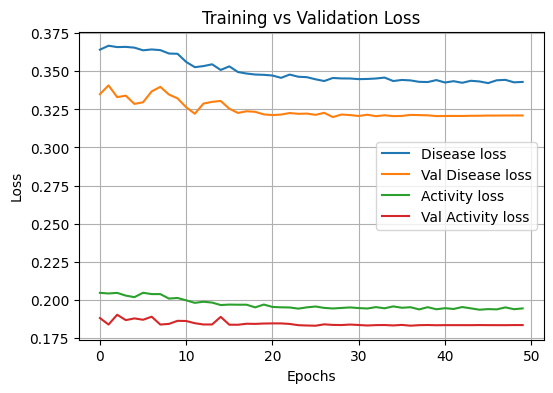

In [34]:
import matplotlib.pyplot as plt

# ✅ Function to plot curves
def plot_curves(history, metric, title):
    plt.figure(figsize=(6,4))
    plt.plot(history.history[f"disease_output_{metric}"], label=f"Disease {metric}")
    plt.plot(history.history[f"val_disease_output_{metric}"], label=f"Val Disease {metric}")
    plt.plot(history.history[f"activity_output_{metric}"], label=f"Activity {metric}")
    plt.plot(history.history[f"val_activity_output_{metric}"], label=f"Val Activity {metric}")
    plt.xlabel("Epochs")
    plt.ylabel(metric.capitalize())
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# ✅ Plot Accuracy curves
plot_curves(history_finetune, "accuracy", "Training vs Validation Accuracy")

# ✅ Plot Loss curves
plot_curves(history_finetune, "loss", "Training vs Validation Loss")


976/976 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


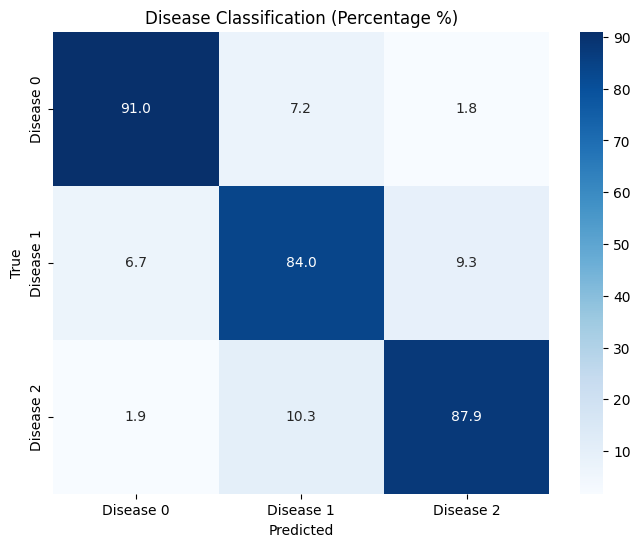

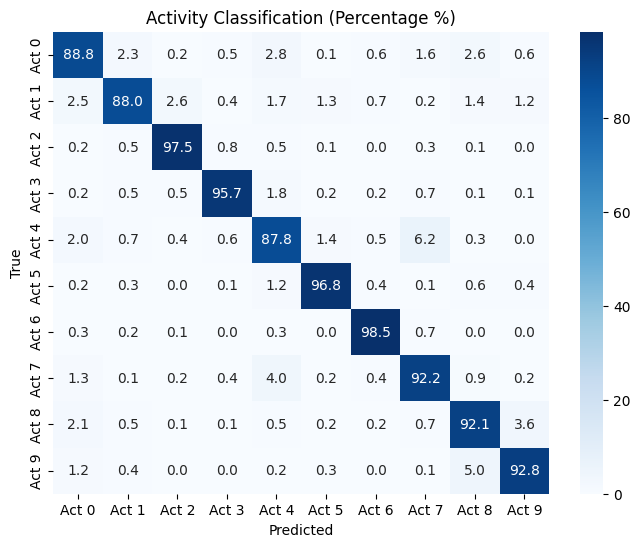



===== 📌 Disease Classification Report =====
              precision    recall  f1-score   support

   Disease 0       0.86      0.91      0.88      7280
   Disease 1       0.88      0.84      0.86     13435
   Disease 2       0.87      0.88      0.87     10507

    accuracy                           0.87     31222
   macro avg       0.87      0.88      0.87     31222
weighted avg       0.87      0.87      0.87     31222



===== 📌 Activity Classification Report =====
              precision    recall  f1-score   support

       Act 0       0.90      0.89      0.89      2645
       Act 1       0.93      0.88      0.91      2630
       Act 2       0.98      0.98      0.98      5173
       Act 3       0.96      0.96      0.96      2557
       Act 4       0.87      0.88      0.87      2622
       Act 5       0.96      0.97      0.96      2574
       Act 6       0.98      0.98      0.98      5266
       Act 7       0.89      0.92      0.90      2535
       Act 8       0.89      0.92      

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ============================================
# 1️⃣ - Get Predictions on Test Set
# ============================================
y_pred_disease, y_pred_activity = model.predict(X_test_f)

# Convert probabilities → class labels
y_pred_disease = np.argmax(y_pred_disease, axis=1)
y_pred_activity = np.argmax(y_pred_activity, axis=1)

y_true_disease = y_disease_test_f
y_true_activity = y_activity_test_f

# ============================================
# 2️⃣ - Function to plot Confusion Matrix with %
# ============================================
def plot_confusion_matrix_with_percent(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm / cm.sum(axis=1, keepdims=True) * 100  # convert to %
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_normalized,
                annot=True,
                fmt=".1f",
                cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{title} (Percentage %)")
    plt.show()
    
    return cm, cm_normalized

# ============================================
# 3️⃣ - Plot Confusion Matrices
# ============================================
disease_classes = ["Disease 0", "Disease 1", "Disease 2"]
activity_classes = [f"Act {i}" for i in range(len(np.unique(y_activity_test_f)))]

cm_disease, cm_disease_percent = plot_confusion_matrix_with_percent(
    y_true_disease, y_pred_disease, disease_classes, "Disease Classification")

cm_activity, cm_activity_percent = plot_confusion_matrix_with_percent(
    y_true_activity, y_pred_activity, activity_classes, "Activity Classification")

# ============================================
# 4️⃣ - Print Detailed Classification Reports
# ============================================
print("\n\n===== 📌 Disease Classification Report =====")
print(classification_report(y_true_disease, y_pred_disease, target_names=disease_classes))

print("\n\n===== 📌 Activity Classification Report =====")
print(classification_report(y_true_activity, y_pred_activity, target_names=activity_classes))

# ============================================
# 5️⃣ - Extract Recall Percentages for Each Class
# ============================================
def print_recall_percent(cm, class_names):
    recalls = np.diag(cm) / cm.sum(axis=1) * 100
    print("\n📌 Recall per Class (%):")
    for name, r in zip(class_names, recalls):
        print(f"{name:15s} : {r:.2f}%")

print("\n\n===== 📌 Disease Recall Percentages =====")
print_recall_percent(cm_disease, disease_classes)

print("\n\n===== 📌 Activity Recall Percentages =====")
print_recall_percent(cm_activity, activity_classes)
